<a href="https://colab.research.google.com/github/wanchenlang-max/econ5200-assignment3/blob/main/Econ_5200_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

In [2]:
np.random.seed(42)

zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)

driver_tips = np.concatenate([zeros, tips])

len(driver_tips), driver_tips[:10]

(250, array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

In [3]:
np.random.seed(42)

B = 10_000
n = len(driver_tips)

boot_medians = np.empty(B)

for b in range(B):
    sample = np.random.choice(driver_tips, size=n, replace=True)
    boot_medians[b] = np.median(sample)

ci_low, ci_high = np.percentile(boot_medians, [2.5, 97.5])
obs_median = np.median(driver_tips)

obs_median, ci_low, ci_high

(np.float64(0.7553316913699188),
 np.float64(0.2642554369019624),
 np.float64(1.3635639228066991))

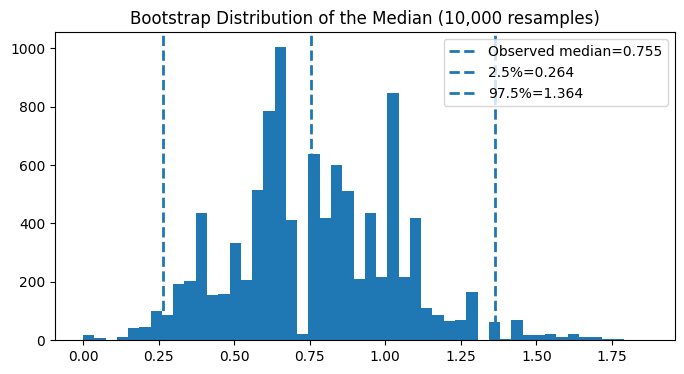

In [4]:
plt.figure(figsize=(8,4))
plt.hist(boot_medians, bins=50)
plt.axvline(obs_median, linestyle='--', linewidth=2, label=f'Observed median={obs_median:.3f}')
plt.axvline(ci_low, linestyle='--', linewidth=2, label=f'2.5%={ci_low:.3f}')
plt.axvline(ci_high, linestyle='--', linewidth=2, label=f'97.5%={ci_high:.3f}')
plt.title("Bootstrap Distribution of the Median (10,000 resamples)")
plt.legend()
plt.show()

In [5]:
np.random.seed(42)

n_control = 500
n_treat = 500

control = np.random.normal(loc=35, scale=5, size=n_control)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=n_treat)

obs_diff = control.mean() - treatment.mean()

control.mean(), treatment.mean(), obs_diff

(np.float64(35.03418997294323),
 np.float64(32.76920784231749),
 np.float64(2.2649821306257394))

In [6]:
np.max(treatment), np.percentile(treatment, [50, 90, 95, 99])

(np.float64(85.88015912929279),
 array([30.30802847, 51.02489349, 60.39816214, 79.70553703]))

In [7]:
np.random.seed(42)

all_data = np.concatenate([control, treatment])
N = len(all_data)

R = 5000
perm_diffs = np.empty(R)

for r in range(R):
    perm = np.random.permutation(all_data)
    pseudo_c = perm[:n_control]
    pseudo_t = perm[n_control:]
    perm_diffs[r] = pseudo_c.mean() - pseudo_t.mean()

p_value_two_sided = np.mean(np.abs(perm_diffs) >= np.abs(obs_diff))
p_value_two_sided

np.float64(0.0004)

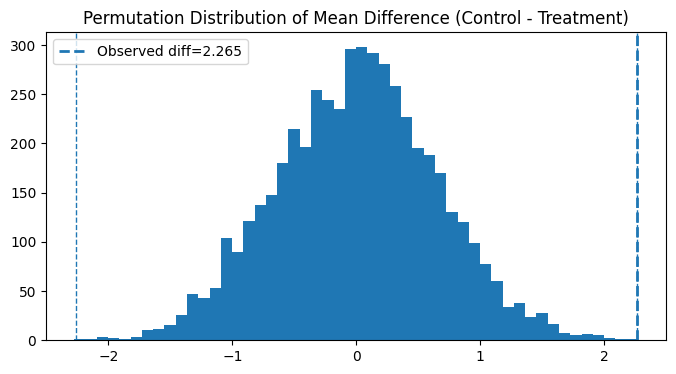

In [8]:
plt.figure(figsize=(8,4))
plt.hist(perm_diffs, bins=50)
plt.axvline(obs_diff, linestyle='--', linewidth=2, label=f'Observed diff={obs_diff:.3f}')
plt.axvline(-abs(obs_diff), linestyle='--', linewidth=1)
plt.axvline(abs(obs_diff), linestyle='--', linewidth=1)
plt.title("Permutation Distribution of Mean Difference (Control - Treatment)")
plt.legend()
plt.show()

In [9]:
import pandas as pd

df = pd.read_csv("swiftcart_loyalty.csv")
df.head()

,subscriber,pre_spend,account_age,support_tickets,post_spend
0,1,57.450712,37,2,85.169648
1,1,47.926035,41,0,72.802404
2,1,59.715328,41,0,79.858905
3,1,72.845448,34,0,80.335466
4,1,46.487699,34,2,67.956227


In [10]:
df.columns

Index(['subscriber', 'pre_spend', 'account_age', 'support_tickets',
       'post_spend'],
      dtype='object')

In [13]:
import pandas as pd
import numpy as np

df = pd.read_csv("swiftcart_loyalty.csv")


D_col = "subscriber"
Y_col = "post_spend"
X_cols = ["pre_spend", "account_age", "support_tickets"]

print(df.head())
print(df[X_cols + [D_col, Y_col]].isna().sum())
print(df[D_col].value_counts())

   subscriber  pre_spend  account_age  support_tickets  post_spend
0           1  57.450712           37                2   85.169648
1           1  47.926035           41                0   72.802404
2           1  59.715328           41                0   79.858905
3           1  72.845448           34                0   80.335466
4           1  46.487699           34                2   67.956227
pre_spend          0
account_age        0
support_tickets    0
subscriber         0
post_spend         0
dtype: int64
subscriber
0    4741
1    4200
Name: count, dtype: int64


In [14]:
D = df[D_col].astype(int)
Y = df[Y_col].astype(float)

naive_sdo = Y[D==1].mean() - Y[D==0].mean()

print("Naive SDO (Subscribers - Non-subscribers) =", naive_sdo)
print("Mean post_spend | D=1 =", Y[D==1].mean())
print("Mean post_spend | D=0 =", Y[D==0].mean())

Naive SDO (Subscribers - Non-subscribers) = 17.570669384521437
Mean post_spend | D=1 = 74.0435860405238
Mean post_spend | D=0 = 56.47291665600237


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

X = df[X_cols].copy()
X = X.fillna(X.median(numeric_only=True))

D = df[D_col].astype(int).values
Y = df[Y_col].astype(float).values

logit = LogisticRegression(max_iter=2000)
logit.fit(X, D)
pscore = logit.predict_proba(X)[:, 1]
df_unmatched = df.copy()
df_unmatched["propensity_score"] = pscore

In [16]:
treated_idx = np.where(D == 1)[0]
control_idx = np.where(D == 0)[0]

treated_ps = pscore[treated_idx].reshape(-1, 1)
control_ps = pscore[control_idx].reshape(-1, 1)

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control_ps)

dist, neighbors = nn.kneighbors(treated_ps, n_neighbors=1, return_distance=True)
matched_control_idx = control_idx[neighbors.flatten()]

ATT = np.mean(Y[treated_idx] - Y[matched_control_idx])

print("ATT (PSM matched) =", ATT)
print("Naive SDO =", naive_sdo)
print("Average match distance (propensity score gap) =", dist.mean())

ATT (PSM matched) = 9.913855182822033
Naive SDO = 17.570669384521437
Average match distance (propensity score gap) = 0.00018953341129930915


In [17]:
df_treated = df_unmatched.iloc[treated_idx].copy()
df_ctrl_matched = df_unmatched.iloc[matched_control_idx].copy()

df_treated["group"] = "treated"
df_ctrl_matched["group"] = "matched_control"

df_matched = pd.concat([df_treated, df_ctrl_matched], axis=0).reset_index(drop=True)

df_unmatched.shape, df_matched.shape

((8941, 6), (8400, 7))

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

def smd(x_treat, x_ctrl):
    mt = np.mean(x_treat)
    mc = np.mean(x_ctrl)
    vt = np.var(x_treat, ddof=1)
    vc = np.var(x_ctrl, ddof=1)
    pooled_sd = np.sqrt((vt + vc) / 2)
    if pooled_sd == 0:
        return 0.0
    return (mt - mc) / pooled_sd


treated_un = df_unmatched[df_unmatched[D_col] == 1]
control_un = df_unmatched[df_unmatched[D_col] == 0]

treated_m = df_matched[df_matched["group"] == "treated"]
control_m = df_matched[df_matched["group"] == "matched_control"]

rows = []
for c in X_cols:
    rows.append({"covariate": c, "stage": "Before Matching", "smd": smd(treated_un[c], control_un[c])})
    rows.append({"covariate": c, "stage": "After Matching",  "smd": smd(treated_m[c], control_m[c])})

smd_df = pd.DataFrame(rows)
smd_df

,covariate,stage,smd
0,pre_spend,Before Matching,0.673959
1,pre_spend,After Matching,0.013664
2,account_age,Before Matching,0.324109
3,account_age,After Matching,-0.015871
4,support_tickets,Before Matching,-0.166146
5,support_tickets,After Matching,0.017112


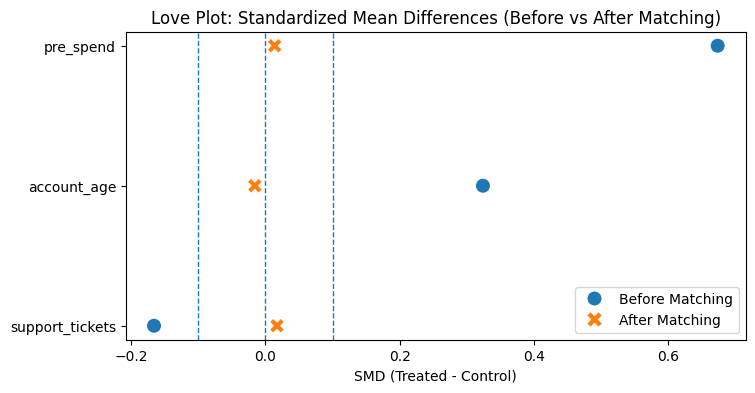

In [19]:
plt.figure(figsize=(8, 4))

sns.scatterplot(data=smd_df, x="smd", y="covariate", hue="stage", style="stage", s=120)

plt.axvline(0, linestyle="--", linewidth=1)
plt.axvline(0.1, linestyle="--", linewidth=1)
plt.axvline(-0.1, linestyle="--", linewidth=1)

plt.title("Love Plot: Standardized Mean Differences (Before vs After Matching)")
plt.xlabel("SMD (Treated - Control)")
plt.ylabel("")
plt.legend(title="")
plt.show()

In [20]:
print("Naive SDO =", naive_sdo)
print("ATT =", ATT)
print(smd_df)

Naive SDO = 17.570669384521437
ATT = 9.913855182822033
         covariate            stage       smd
0        pre_spend  Before Matching  0.673959
1        pre_spend   After Matching  0.013664
2      account_age  Before Matching  0.324109
3      account_age   After Matching -0.015871
4  support_tickets  Before Matching -0.166146
5  support_tickets   After Matching  0.017112
